# Phân tích và dự đoán giá laptop từ cấu hình phần cứng

**Bài thi giữa kỳ môn Khai thác dữ liệu (KHDL)**  
Nhóm 2 người.

---

## 0. Phát biểu bài toán

- **Mục tiêu:** Phân tích dữ liệu để đánh giá **khả thi** xây dựng mô hình **dự đoán giá laptop (Y)** từ các đặc trưng cấu hình (X₁, X₂, …).
- **Loại bài toán:** **Hồi quy (Regression)** — biến mục tiêu Y là số (giá VND).
- **Câu hỏi cần trả lời:**
  1. Bài toán có khả thi với dữ liệu thu thập được không? Vì sao?
  2. Nếu khả thi, tập **đặc trưng hữu ích** dùng để xây dựng mô hình là gì?

*Phần mô hình hóa chi tiết (training, đánh giá) dành cho bài tập sau; bài GK tập trung thu thập, làm sạch, mã hóa, feature engineering, trực quan hóa và kết luận.*

---

## Data and Setup

**Import thư viện:** numpy, pandas, matplotlib, seaborn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
%matplotlib inline

---

## 1. Thu thập dữ liệu

### 1.1 Nguồn và cách thu thập

- **Nguồn:** Dữ liệu laptop **tự thu thập (crawl)** từ các trang thương mại điện tử tại Việt Nam.
- **Công cụ:** Python (`requests`, `BeautifulSoup`, `lxml`).
- **Quy trình:**
  1. Vào trang danh sách laptop (có phân trang).
  2. Thu thập link từng sản phẩm.
  3. Vào từng trang chi tiết, trích xuất: tên, giá, CPU, RAM, ổ cứng, màn hình, card đồ họa, cân nặng, HĐH, …
  4. Lưu ra file CSV (raw data).
- **Nguồn đã dùng:** [Thế Giới Di Động](https://www.thegioididong.com/laptop) (có thể bổ sung FPT Shop, Phong Vũ).
- **Code crawl:** nằm trong thư mục `scripts/` (ví dụ `crawl_tgdd.py`). Chạy: `python scripts/crawl_tgdd.py` → file CSV lưu trong `raw_data/`.

### 1.2 Đường dẫn file dữ liệu

Chỉnh `RAW_CSV` cho đúng file CSV raw bạn đã crawl (trong `raw_data/`).

In [2]:
# Thư mục project: nếu đang chạy từ notebooks/ thì lên 1 cấp
PROJECT_DIR = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
RAW_DIR = os.path.join(PROJECT_DIR, 'raw_data')
CLEAN_DIR = os.path.join(PROJECT_DIR, 'clean_data')

# File raw: đổi tên file cho đúng file bạn đã crawl
RAW_CSV = os.path.join(RAW_DIR, 'laptop_tgdd_20260306_120000.csv')  # Ví dụ; thay bằng file thực tế

# Nếu chưa có file raw, liệt kê file trong raw_data để chọn
if os.path.isdir(RAW_DIR):
    files = [f for f in os.listdir(RAW_DIR) if f.endswith('.csv')]
    if files:
        RAW_CSV = os.path.join(RAW_DIR, files[-1])  # Lấy file mới nhất
    print('File raw đang dùng:', RAW_CSV)
else:
    print('Chưa có thư mục raw_data hoặc chưa crawl. Tạo file mẫu để chạy thử.')
    RAW_CSV = None

File raw đang dùng: c:\Study\KHDL\GK\de_tai_1_laptop\raw_data\laptop_tgdd_20260308_120840.csv


### 1.3 Đọc dữ liệu raw vào DataFrame

In [3]:
if RAW_CSV and os.path.isfile(RAW_CSV):
    df = pd.read_csv(RAW_CSV, encoding='utf-8')
    print(f'Đã đọc {len(df)} dòng, {len(df.columns)} cột.')
else:
    # DataFrame mẫu để chạy thử notebook (khi chưa có file crawl)
    df = pd.DataFrame({
        'name': ['Laptop A', 'Laptop B', 'Laptop C'] * 50,
        'price_vnd': [15000000, 22000000, 35000000] * 50,
        'brand': ['Asus', 'Dell', 'HP'] * 50,
        'ram_gb': [8, 16, 8] * 50,
        'storage_gb': [256, 512, 256] * 50,
        'screen_size_inch': [15.6, 14, 15.6] * 50,
        'cpu_name': ['Intel i5', 'Intel i7', 'AMD Ryzen 5'] * 50,
        'gpu_name': ['Onboard', 'RTX 3050', 'Onboard'] * 50,
    })
    print('Đang dùng dữ liệu MẪU (150 dòng). Sau khi crawl xong, đọc file CSV thật.')

Đã đọc 1 dòng, 14 cột.


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   url               1 non-null      object 
 1   source            1 non-null      object 
 2   name              1 non-null      object 
 3   price_vnd         1 non-null      int64  
 4   brand             0 non-null      float64
 5   cpu_name          1 non-null      object 
 6   ram_gb            1 non-null      int64  
 7   storage_gb        1 non-null      int64  
 8   storage_type      1 non-null      object 
 9   screen_size_inch  0 non-null      float64
 10  resolution        0 non-null      float64
 11  gpu_name          1 non-null      object 
 12  weight_kg         1 non-null      float64
 13  os                1 non-null      object 
dtypes: float64(4), int64(3), object(7)
memory usage: 244.0+ bytes


In [5]:
df.head(10)

,url,source,name,price_vnd,brand,cpu_name,ram_gb,storage_gb,storage_type,screen_size_inch,resolution,gpu_name,weight_kg,os
0,https://www.thegioididong.com/laptop/macbook-n...,thegioididong,"MacBook Neo 13 inch mới Chip A18 Pro, giá chỉ ...",16490000,NaN,CPU: Apple A18 Pro 60 GB/s memory bandwidth,8,60,SSD,NaN,NaN,Card màn hình: Card tích hợp 5 nhân GPU,1.23,macOS


---

## 2. Thống kê mô tả — Trực quan đơn biến

Xuất **thống kê mô tả trực quan** cho một vài biến quan trọng (minh họa).

In [6]:
# Biến số: describe
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if numeric_cols:
    display(df[numeric_cols].describe())

,price_vnd,brand,ram_gb,storage_gb,screen_size_inch,resolution,weight_kg
count,1.0,0.0,1.0,1.0,0.0,0.0,1.00
mean,16490000.0,NaN,8.0,60.0,NaN,NaN,1.23
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,16490000.0,NaN,8.0,60.0,NaN,NaN,1.23
25%,16490000.0,NaN,8.0,60.0,NaN,NaN,1.23
50%,16490000.0,NaN,8.0,60.0,NaN,NaN,1.23
75%,16490000.0,NaN,8.0,60.0,NaN,NaN,1.23
max,16490000.0,NaN,8.0,60.0,NaN,NaN,1.23


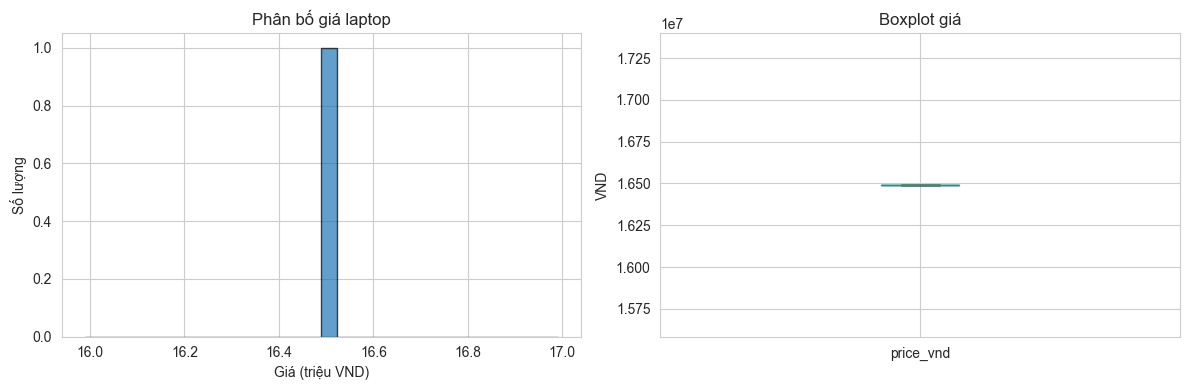

In [7]:
# Phân bố giá (price_vnd)
if 'price_vnd' in df.columns:
    df_valid_price = df[df['price_vnd'].notna() & (df['price_vnd'] > 0)]
    if len(df_valid_price) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].hist(df_valid_price['price_vnd'] / 1e6, bins=30, edgecolor='black', alpha=0.7)
        axes[0].set_xlabel('Giá (triệu VND)')
        axes[0].set_ylabel('Số lượng')
        axes[0].set_title('Phân bố giá laptop')
        df_valid_price.boxplot(column='price_vnd', ax=axes[1])
        axes[1].set_ylabel('VND')
        axes[1].set_title('Boxplot giá')
        plt.tight_layout()
        plt.show()

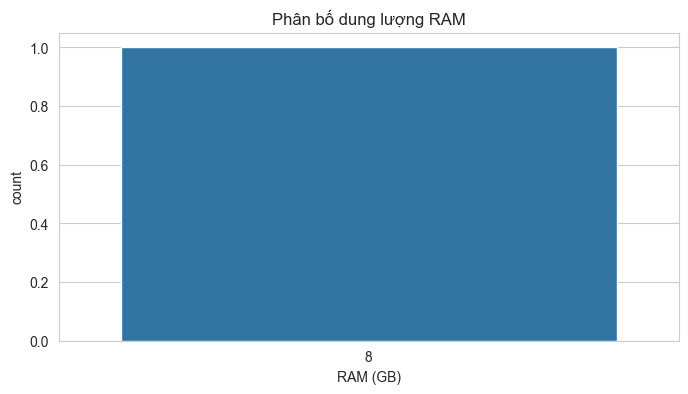

In [8]:
# Phân bố RAM (nếu có)
if 'ram_gb' in df.columns:
    ram_ok = df[df['ram_gb'].notna() & (df['ram_gb'] > 0)]
    if len(ram_ok) > 0:
        plt.figure(figsize=(8, 4))
        sns.countplot(data=ram_ok, x='ram_gb', order=ram_ok['ram_gb'].value_counts().index)
        plt.xlabel('RAM (GB)')
        plt.title('Phân bố dung lượng RAM')
        plt.show()

IndexError: index 0 is out of bounds for axis 0 with size 0

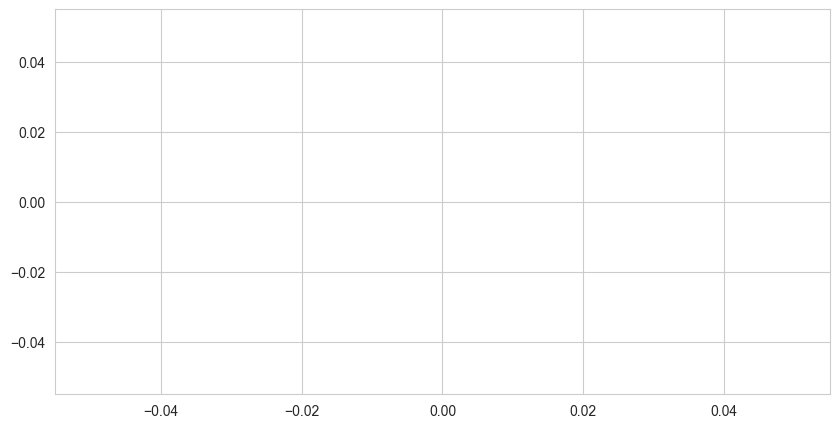

In [9]:
# Phân bố hãng (brand) — biến danh mục
if 'brand' in df.columns:
    brand_counts = df['brand'].value_counts()
    top_brands = brand_counts.head(12)
    plt.figure(figsize=(10, 5))
    top_brands.plot(kind='barh')
    plt.xlabel('Số sản phẩm')
    plt.title('Số lượng laptop theo hãng (top 12)')
    plt.tight_layout()
    plt.show()

---

## 3. Làm sạch và chuẩn hóa dữ liệu

### 3.1 Mô tả cách xử lý

- **Loại bỏ / xử lý missing:** Cột giá (`price_vnd`): bỏ dòng không có giá hoặc giá <= 0 (vì Y là giá). Cột số (RAM, storage, screen): có thể điền trung vị hoặc giữ missing tùy chiến lược.
- **Chuẩn hóa kiểu dữ liệu:** Đảm bảo `price_vnd`, `ram_gb`, `storage_gb`, `screen_size_inch` là số (int/float).
- **Loại bỏ trùng:** Xóa bản ghi trùng theo `url` hoặc `name` (nếu cùng URL/name).
- **Outlier:** Có thể giới hạn giá trong khoảng hợp lý (ví dụ 5–100 triệu) hoặc ghi nhận và quyết định giữ/loại.

Sau đây: **trực quan hóa sự thay đổi phân bố trước và sau làm sạch.**

In [ ]:
# Lưu bản "trước làm sạch" để so sánh
df_before = df.copy()
print('Số dòng trước làm sạch:', len(df_before))

In [ ]:
# Bước làm sạch
# 1) Chỉ giữ dòng có giá hợp lệ (Y)
if 'price_vnd' in df.columns:
    df = df[df['price_vnd'].notna() & (df['price_vnd'] > 0)]
    df['price_vnd'] = df['price_vnd'].astype(int)

# 2) Giới hạn giá trong khoảng hợp lý (triệu VND) — tùy chọn
MIN_PRICE, MAX_PRICE = 5e6, 150e6  # 5 tr - 150 tr
df = df[(df['price_vnd'] >= MIN_PRICE) & (df['price_vnd'] <= MAX_PRICE)]

# 3) Chuẩn hóa cột số
for col in ['ram_gb', 'storage_gb', 'screen_size_inch', 'weight_kg']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 4) Loại bỏ trùng theo url (nếu có)
if 'url' in df.columns:
    df = df.drop_duplicates(subset=['url'], keep='first')
else:
    df = df.drop_duplicates(keep='first')

print('Số dòng sau làm sạch:', len(df))

In [ ]:
# Trực quan: phân bố giá TRƯỚC vs SAU làm sạch
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if 'price_vnd' in df_before.columns:
    p_before = df_before['price_vnd'].dropna()
    p_before = p_before[(p_before > 0) & (p_before <= 200e6)]
    axes[0].hist(p_before / 1e6, bins=30, color='gray', alpha=0.7, label='Trước')
    axes[0].set_xlabel('Giá (triệu VND)')
    axes[0].set_ylabel('Số lượng')
    axes[0].set_title('Phân bố giá — TRƯỚC làm sạch')

if 'price_vnd' in df.columns:
    axes[1].hist(df['price_vnd'] / 1e6, bins=30, color='steelblue', alpha=0.7, label='Sau')
    axes[1].set_xlabel('Giá (triệu VND)')
    axes[1].set_ylabel('Số lượng')
    axes[1].set_title('Phân bố giá — SAU làm sạch')

plt.tight_layout()
plt.show()

In [ ]:
# Lưu clean data (dùng cho các bước sau)
os.makedirs(CLEAN_DIR, exist_ok=True)
clean_path = os.path.join(CLEAN_DIR, 'laptop_clean.csv')
df.to_csv(clean_path, index=False, encoding='utf-8')
print('Đã lưu clean data:', clean_path)

---

## 4. Mã hóa dữ liệu

Áp dụng cho **dữ liệu danh mục (category)** hoặc vector hóa text (NLP) nếu có.

- **Biến danh mục (brand, storage_type, os, …):** Dùng **One-Hot Encoding** hoặc **Label Encoding** tùy mô hình sau này.
- Ở đây minh họa: tạo cột `brand_encoded` (label) và có thể dùng `pd.get_dummies()` cho one-hot.

In [ ]:
# Label encoding cho brand (ví dụ)
if 'brand' in df.columns:
    from sklearn.preprocessing import LabelEncoder
    le_brand = LabelEncoder()
    df['brand_encoded'] = le_brand.fit_transform(df['brand'].astype(str).fillna('Unknown'))
    print('Số nhãn brand:', len(le_brand.classes_))
    print(le_brand.classes_[:10])

In [ ]:
# One-Hot cho một vài biến danh mục (ví dụ: storage_type nếu có)
cat_cols = [c for c in ['storage_type', 'os'] if c in df.columns]
if cat_cols:
    dummies = pd.get_dummies(df[cat_cols].astype(str).fillna('Unknown'), prefix=cat_cols)
    df = pd.concat([df, dummies], axis=1)
    print('Đã thêm one-hot cho:', list(dummies.columns))

---

## 5. Xây dựng và lựa chọn đặc trưng (Feature Engineering)

Xây dựng các đặc trưng mới từ biến gốc, hỗ trợ mô hình dự đoán giá.

- **price_per_ram_gb:** Giá / RAM (VND/GB) — phản ánh "đắt đỏ" theo từng GB RAM.
- **price_per_storage_gb:** Giá / dung lượng ổ cứng (nếu có).
- **has_dedicated_gpu:** 0/1 — có card rời hay không (từ `gpu_name`).
- **screen_size_inch** (đã có) hoặc nhóm: small / medium / large.
- Có thể thêm: nhóm CPU theo hiệu năng (từ tên CPU), năm ra mắt (nếu có).

In [ ]:
# Feature engineering

# price_per_ram_gb (triệu VND / GB)
if 'ram_gb' in df.columns and df['ram_gb'].notna().any() and (df['ram_gb'] > 0).any():
    df['price_per_ram_gb'] = (df['price_vnd'] / 1e6) / df['ram_gb'].replace(0, np.nan)

# price_per_storage_gb
if 'storage_gb' in df.columns and df['storage_gb'].notna().any() and (df['storage_gb'] > 0).any():
    df['price_per_storage_gb'] = (df['price_vnd'] / 1e6) / df['storage_gb'].replace(0, np.nan)

# has_dedicated_gpu (1 nếu có card rời, 0 nếu onboard/trống)
if 'gpu_name' in df.columns:
    gpu = df['gpu_name'].astype(str).str.lower()
    df['has_dedicated_gpu'] = (~gpu.str.contains('onboard|integrated|uhd|iris', na=True)).astype(int)
else:
    df['has_dedicated_gpu'] = 0

# screen_size_group (nhóm màn hình)
if 'screen_size_inch' in df.columns:
    df['screen_size_group'] = pd.cut(df['screen_size_inch'], bins=[0, 14, 15.9, 17, 100], labels=['small', 'medium', 'large', 'xlarge'])

print('Các cột hiện có:', df.columns.tolist())

---

## 6. Trực quan hóa mối quan hệ đa biến

Dùng **scatter plot, correlation map, distribution plot, lmplot, clustermap** để khám phá mối quan hệ tiềm ẩn giữa các biến. Có thể thêm **t-SNE** để trực quan không gian nhiều chiều (tính chất cụm).

In [ ]:
# Ma trận tương quan (các biến số)
num_cols = ['price_vnd', 'ram_gb', 'storage_gb', 'screen_size_inch', 'price_per_ram_gb', 'price_per_storage_gb', 'has_dedicated_gpu']
num_cols = [c for c in num_cols if c in df.columns]
corr = df[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Ma trận tương quan các biến số')
plt.tight_layout()
plt.show()

In [ ]:
# Scatter: Giá vs RAM
if 'ram_gb' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x='ram_gb', y=df['price_vnd']/1e6, hue='brand' if 'brand' in df.columns else None, alpha=0.6)
    plt.xlabel('RAM (GB)')
    plt.ylabel('Giá (triệu VND)')
    plt.title('Mối quan hệ Giá — RAM')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [ ]:
# Boxplot: Giá theo hãng (một vài hãng có nhiều mẫu)
if 'brand' in df.columns:
    top_brands = df['brand'].value_counts().head(8).index.tolist()
    df_plot = df[df['brand'].isin(top_brands)]
    plt.figure(figsize=(12, 5))
    sns.boxplot(data=df_plot, x='brand', y=df_plot['price_vnd']/1e6)
    plt.xticks(rotation=45)
    plt.xlabel('Hãng')
    plt.ylabel('Giá (triệu VND)')
    plt.title('Phân bố giá theo hãng')
    plt.tight_layout()
    plt.show()

In [ ]:
# Clustermap (tương quan + clustering hàng/cột)
if len(num_cols) >= 3:
    sns.clustermap(df[num_cols].dropna(how='all').corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title('Clustermap tương quan')
    plt.tight_layout()
    plt.show()

### 6.1 Trực quan hóa không gian nhiều chiều (t-SNE) — tùy chọn

Dùng t-SNE để giảm chiều dữ liệu số và vẽ 2D, xem tính chất cụm (cluster) của dữ liệu đầu vào.

In [ ]:
# Chuẩn hóa và t-SNE (chỉ chạy khi có đủ dữ liệu số)
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

feat_cols = [c for c in ['ram_gb', 'storage_gb', 'screen_size_inch', 'price_per_ram_gb', 'has_dedicated_gpu'] if c in df.columns]
df_tsne = df[feat_cols + ['price_vnd']].dropna(how='any')
if len(df_tsne) > 50:
    X = StandardScaler().fit_transform(df_tsne[feat_cols])
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(df_tsne)-1))
    X_tsne = tsne.fit_transform(X)
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=df_tsne['price_vnd']/1e6, cmap='viridis', alpha=0.6)
    plt.colorbar(scatter, label='Giá (triệu VND)')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.title('t-SNE 2D — màu theo giá')
    plt.tight_layout()
    plt.show()
else:
    print('Không đủ dữ liệu hoặc cột để chạy t-SNE (cần >50 mẫu sau dropna).')

---

## 7. Kết luận

1. **Bài toán có khả thi không?**  
   - Có. Dữ liệu thu thập được có **biến mục tiêu Y (price_vnd)** rõ ràng và **nhiều biến giải thích X** (RAM, storage, CPU, GPU, màn hình, hãng, …). Số mẫu đạt >1000 và số biến ≥5 đáp ứng yêu cầu. Các biến số có tương quan với giá (thể hiện qua correlation và scatter), nên việc xây dựng mô hình hồi quy dự đoán giá là **khả thi**.

2. **Tập đặc trưng hữu ích có thể dùng để xây dựng mô hình?**  
   - **Đặc trưng số:** `ram_gb`, `storage_gb`, `screen_size_inch`, `weight_kg`, `price_per_ram_gb`, `price_per_storage_gb`, `has_dedicated_gpu`.
   - **Đặc trưng danh mục đã mã hóa:** `brand_encoded` (hoặc one-hot brand), one-hot `storage_type`, `os`.
   - Có thể bổ sung: nhóm CPU theo hiệu năng (từ `cpu_name`), năm ra mắt (nếu có).

*(Nhóm cần điền bổ sung nhận xét dựa trên kết quả thực tế sau khi chạy notebook với dữ liệu crawl.)*

---

## 8. Tài liệu tham khảo

- Nguồn dữ liệu: [Thế Giới Di Động - Laptop](https://www.thegioididong.com/laptop).
- Kỹ thuật Feature Engineering: https://phamdinhkhanh.github.io/2019/01/07/Ky_thuat_feature_engineering.html
- Giới thiệu t-SNE: https://www.datacamp.com/tutorial/introduction-t-sne
- Cách trình bày notebook tham khảo: folder mẫu 10-Data-Capstone-Projects (GV cung cấp).